# **Temporal Convolutional Network Baseline All Sensors**

## **Libraries Import**

In [1]:
from preprocessing import CMAPSS, preprocessing, create_windows
from Models import TCNRegressor
from Training import train
from Testing import test
from dataloading import load_data
from torch.utils.data import DataLoader
import torch
from torch import nn
from plots import plot_predictions

### **GPU check**

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.11.0+cu128
CUDA available: True
Current GPU: NVIDIA GeForce RTX 4060 Ti
GPU count: 1
MPS available: False


### **Data load**

In [4]:
# data loading
filename = '../N-CMAPSS_DS02-006.h5'
W, X_s, X_v, T, Y, A, W_var, X_s_var, X_v_var, T_var, A_var, train_df, test_df = load_data(filename)
print(f"Unique units in train_df: {train_df['unit'].unique()}")
print(f"Shape of train_df: {train_df.shape}")
train_df.head()



Operation time (min):  0.02421875

W shape: (6517190, 4)
X_s shape: (6517190, 14)
X_v shape: (6517190, 14)
T shape: (6517190, 10)
A shape: (6517190, 4)
Unique units in train_df: [ 2  5 10 16 18 20]
Shape of train_df: (5263447, 37)


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,W25,W31,W32,W48,W50,SmFan,SmLPC,SmHPC,phi,RUL
0,2,1.0,3,1,10005.0,0.448497,76.903748,502.420918,600.148034,1438.498187,...,228.487065,26.498785,15.899271,215.844851,228.411666,16.648833,9.898130,25.376144,41.893990,74.0
1,2,1.0,3,1,10013.0,0.447741,76.903748,502.326114,600.055894,1438.350208,...,228.383505,26.486552,15.891931,215.745634,228.307014,16.639222,9.904927,25.380549,41.884434,74.0
2,2,1.0,3,1,10017.0,0.448938,77.079529,502.416067,600.210756,1439.109101,...,228.661083,26.519340,15.911604,216.019054,228.592279,16.649823,9.923503,25.318848,41.953848,74.0
3,2,1.0,3,1,10024.0,0.449883,77.079529,502.469893,600.369717,1439.240230,...,228.768625,26.532044,15.919226,216.121238,228.702994,16.653812,9.905518,25.361981,41.914342,74.0
4,2,1.0,3,1,10031.0,0.449379,77.079529,502.401271,600.298227,1439.064004,...,228.653631,26.518460,15.911076,216.008509,228.584788,16.649031,9.897465,25.363994,41.911503,74.0


In [4]:
print(f"Unique units in test_df: {test_df['unit'].unique()}")
print(f"Shape of test_df: {test_df.shape}")
test_df.head()

Unique units in test_df: [11 14 15]
Shape of test_df: (1253743, 37)


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,W25,W31,W32,W48,W50,SmFan,SmLPC,SmHPC,phi,RUL
0,11,1.0,3,1,10014.0,0.457506,77.25531,503.176696,601.369822,1441.086963,...,229.763207,26.649529,15.989717,217.085529,229.722454,16.745510,9.812495,25.345244,41.971419,58.0
1,11,1.0,3,1,10020.0,0.457947,77.25531,503.192949,601.381211,1441.055436,...,229.736365,26.646358,15.987815,217.058720,229.694212,16.751997,9.806257,25.346932,41.971470,58.0
2,11,1.0,3,1,10029.0,0.458451,77.25531,503.203187,601.392126,1441.063188,...,229.719527,26.644369,15.986621,217.043190,229.677650,16.758975,9.804009,25.348326,41.969940,58.0
3,11,1.0,3,1,10034.0,0.458136,77.25531,503.158580,601.348485,1440.964145,...,229.655911,26.636854,15.982113,216.981145,229.612403,16.755378,9.803649,25.352080,41.964794,58.0
4,11,1.0,3,1,10045.0,0.458010,77.25531,503.105629,601.285695,1440.852510,...,229.561414,26.625692,15.975415,216.890123,229.516137,16.753262,9.806697,25.351024,41.963540,58.0


### **Data preprocessing**

In [ ]:
features = W_var + X_s_var + X_v_var # features selection

X_train_scaled_df, X_test_scaled_df, Y_train, Y_test = preprocessing(True, train_df, test_df, features)
print("Preprocessing completed.")
print("Training set shape:", X_train_scaled_df.shape, "Training labels shape:", Y_train.shape)
print("Testing set shape:", X_test_scaled_df.shape, "Testing labels shape:", Y_test.shape)

✓ Data Normalization

Preprocessing completed.
Training set shape: (5263447, 35) Training labels shape: (5263447,)
Testing set shape: (1253743, 35) Testing labels shape: (1253743,)


### **Window processing**

In [ ]:
train_engine_df = X_train_scaled_df[X_train_scaled_df['unit'] != 18]
val_engine_df   = X_train_scaled_df[X_train_scaled_df['unit'] == 18]

print(f"Shape of train_engine_df: {train_engine_df.shape} and engine units: {train_engine_df['unit'].unique()}")
print(f"Shape of val_engine_df: {val_engine_df.shape} and engine units: {val_engine_df['unit'].unique()}")
print(f"Shape of X_test_scaled_df: {X_test_scaled_df.shape} and engine units: {X_test_scaled_df['unit'].unique()}")

X_windows_train, Y_windows_train = create_windows(train_engine_df, features, window_size=50, stride=15)
X_windows_val, Y_windows_val     = create_windows(val_engine_df, features, window_size=50, stride=15)
X_windows_test, Y_windows_test = create_windows(X_test_scaled_df, features, window_size=50, stride=15)

print("X train normalized windows shape:",X_windows_train.shape,"\n Y train windows  shape:" , Y_windows_train.shape) 
print("X val windows shape:",X_windows_val.shape,"\n Y val windows  shape:" , Y_windows_val.shape) # engine (18) for validating
print("X test windows shape:",X_windows_test.shape,"\n Y test windows  shape:" , Y_windows_test.shape) 


Shape of train_engine_df: (4372728, 35) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 35) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 35) and engine units: [11 14 15]
X train normalized windows shape: (291501, 50, 32) 
 Y train windows  shape: (291501,)
X val windows shape: (59378, 50, 32) 
 Y val windows  shape: (59378,)
X test windows shape: (83574, 50, 32) 
 Y test windows  shape: (83574,)


### **Dataset & dataloader setup**

In [6]:
dataset_train = CMAPSS(X_windows_train, Y_windows_train)
dataset_val   = CMAPSS(X_windows_val, Y_windows_val)
dataset_test  = CMAPSS(X_windows_test, Y_windows_test)

train_loader = DataLoader(dataset_train, batch_size=64, shuffle=True)
val_loader   = DataLoader(dataset_val, batch_size=64, shuffle=False)
test_loader  = DataLoader(dataset_test, batch_size=64, shuffle=False)

oneloader = next(iter(train_loader))
print(type(oneloader))
print(len(oneloader))
for item in oneloader:
    print(type(item), getattr(item, "shape", None))

<class 'list'>
2
<class 'torch.Tensor'> torch.Size([64, 50, 32])
<class 'torch.Tensor'> torch.Size([64, 1])


### **Model setup**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TCNRegressor(
    num_features=len(features),
    num_channels=(64, 64, 64),
    kernel_size=3,
    dropout=0.1
)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-2)
trained_model, train_preds, train_targets, val_preds, val_targets = train(
    criterion, optimizer, train_loader, val_loader, model, num_epochs=1
)
test_loss, test_rmse, test_nasa, test_preds, test_targets = test(
    trained_model, test_loader, criterion
)
plot_predictions(train_targets, train_preds, split_name="Train")
plot_predictions(val_targets, val_preds, split_name="Validation")
plot_predictions(test_targets, test_preds, split_name="Test")

## **Training & Testing**

#### **Train with physical & virtual sensors**

Configuration: lr: 0.001, dropout: 0.1, num of channels : (32, 64, 64), kernel size: 3
cuda
cuda:0
Epoch 1/20 - LR: 0.001000 - Train Loss: 171.4680 - Train RMSE: 13.0946 - Train NASA mean: 2.6479 - Train NASA total: 771852.13 - Val Loss: 70.4961 - Val RMSE: 8.3962 - Val NASA mean: 1.2060 - Val NASA total: 71608.20
Epoch 2/20 - LR: 0.001000 - Train Loss: 103.0162 - Train RMSE: 10.1497 - Train NASA mean: 1.4450 - Train NASA total: 421224.12 - Val Loss: 30.5491 - Val RMSE: 5.5271 - Val NASA mean: 0.6152 - Val NASA total: 36530.54
Epoch 3/20 - LR: 0.001000 - Train Loss: 92.6618 - Train RMSE: 9.6261 - Train NASA mean: 1.3077 - Train NASA total: 381185.48 - Val Loss: 30.6965 - Val RMSE: 5.5404 - Val NASA mean: 0.6496 - Val NASA total: 38570.00
Epoch 4/20 - LR: 0.001000 - Train Loss: 86.4629 - Train RMSE: 9.2985 - Train NASA mean: 1.2268 - Train NASA total: 357615.40 - Val Loss: 47.3486 - Val RMSE: 6.8810 - Val NASA mean: 0.8850 - Val NASA total: 52551.86
Epoch 5/20 - LR: 0.001000 - Train Los

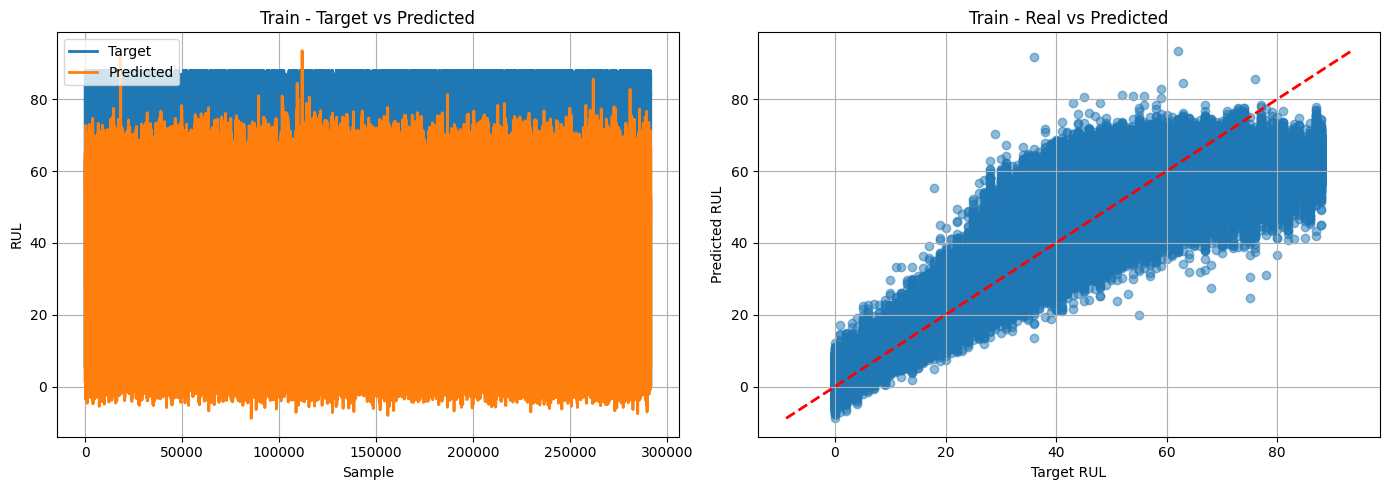

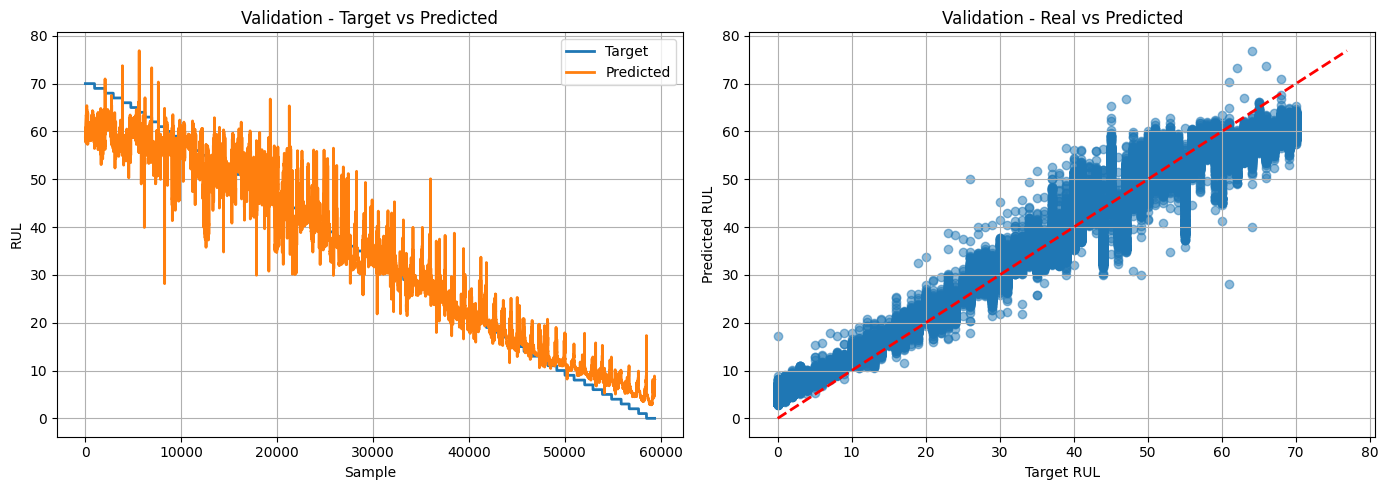

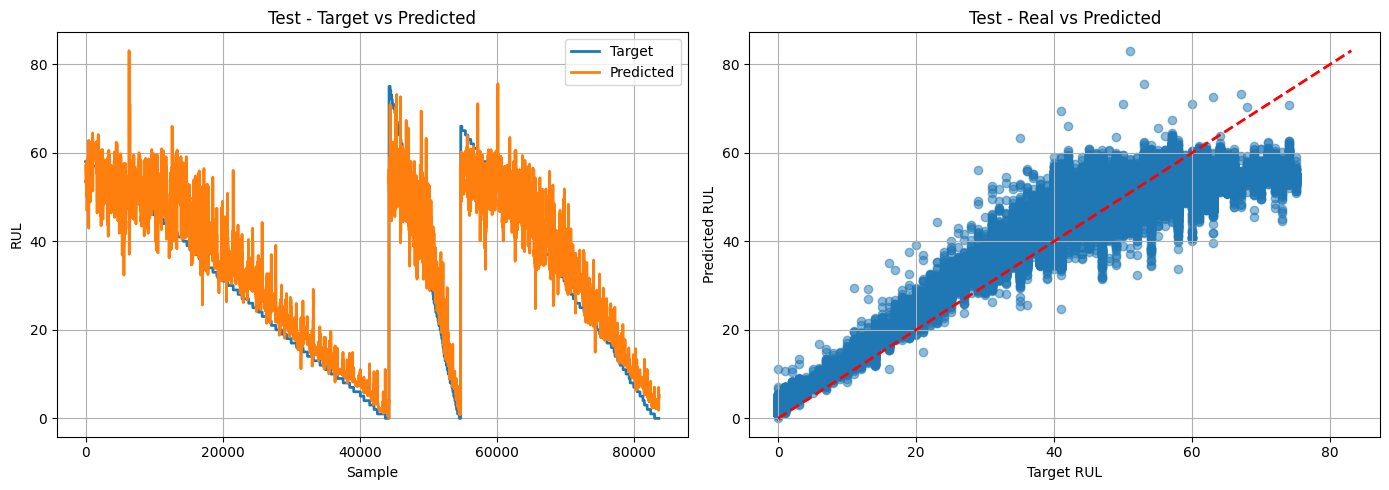

Configuration: lr: 0.0005, dropout: 0.2, num of channels : (64, 64, 64), kernel size: 4
cuda
cuda:0
Epoch 1/20 - LR: 0.000500 - Train Loss: 187.2075 - Train RMSE: 13.6824 - Train NASA mean: 2.8821 - Train NASA total: 840126.07 - Val Loss: 175.4160 - Val RMSE: 13.2445 - Val NASA mean: 1.7961 - Val NASA total: 106649.54
Epoch 2/20 - LR: 0.000500 - Train Loss: 104.7429 - Train RMSE: 10.2344 - Train NASA mean: 1.4662 - Train NASA total: 427385.21 - Val Loss: 39.3766 - Val RMSE: 6.2751 - Val NASA mean: 0.7132 - Val NASA total: 42347.62
Epoch 3/20 - LR: 0.000500 - Train Loss: 90.5948 - Train RMSE: 9.5181 - Train NASA mean: 1.2767 - Train NASA total: 372148.91 - Val Loss: 33.6967 - Val RMSE: 5.8049 - Val NASA mean: 0.6270 - Val NASA total: 37227.28
Epoch 4/20 - LR: 0.000500 - Train Loss: 83.5928 - Train RMSE: 9.1429 - Train NASA mean: 1.1833 - Train NASA total: 344934.69 - Val Loss: 62.0217 - Val RMSE: 7.8754 - Val NASA mean: 1.1171 - Val NASA total: 66333.97
Epoch 5/20 - LR: 0.000500 - Train

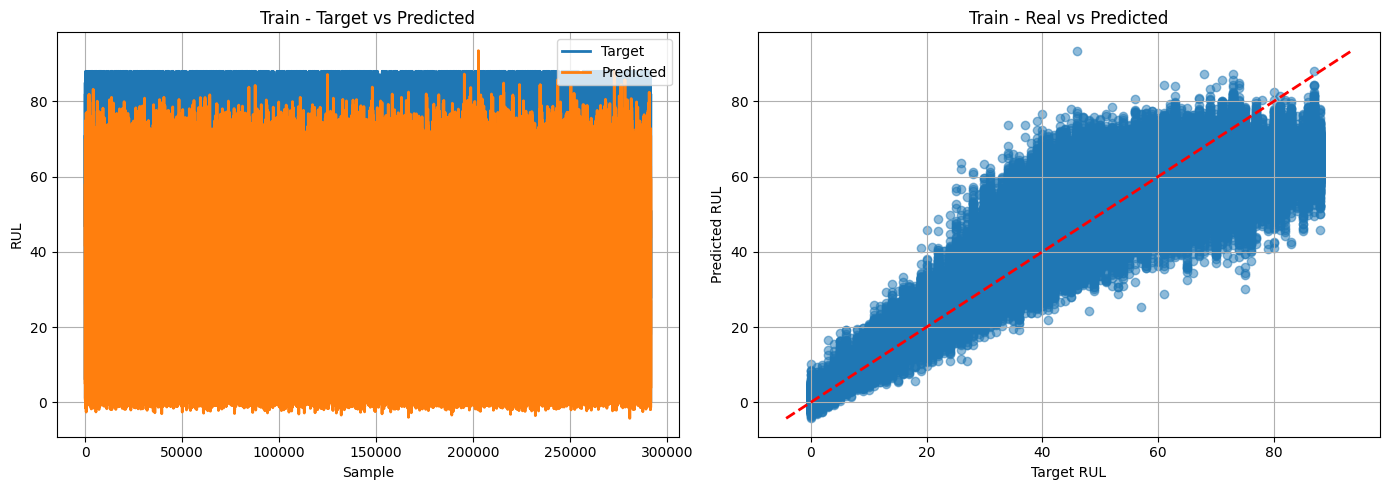

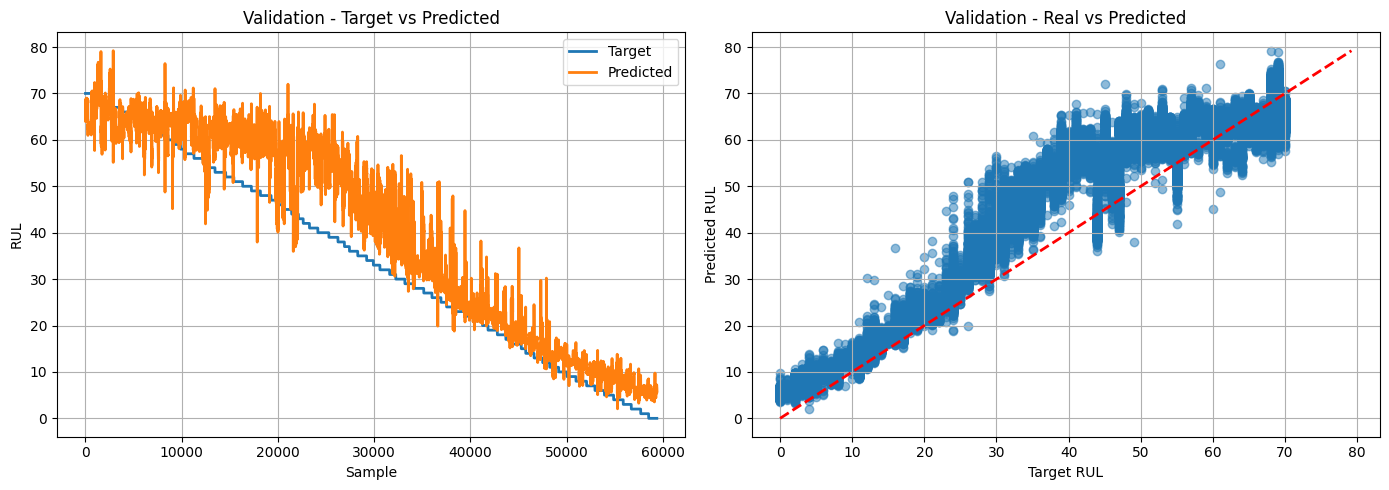

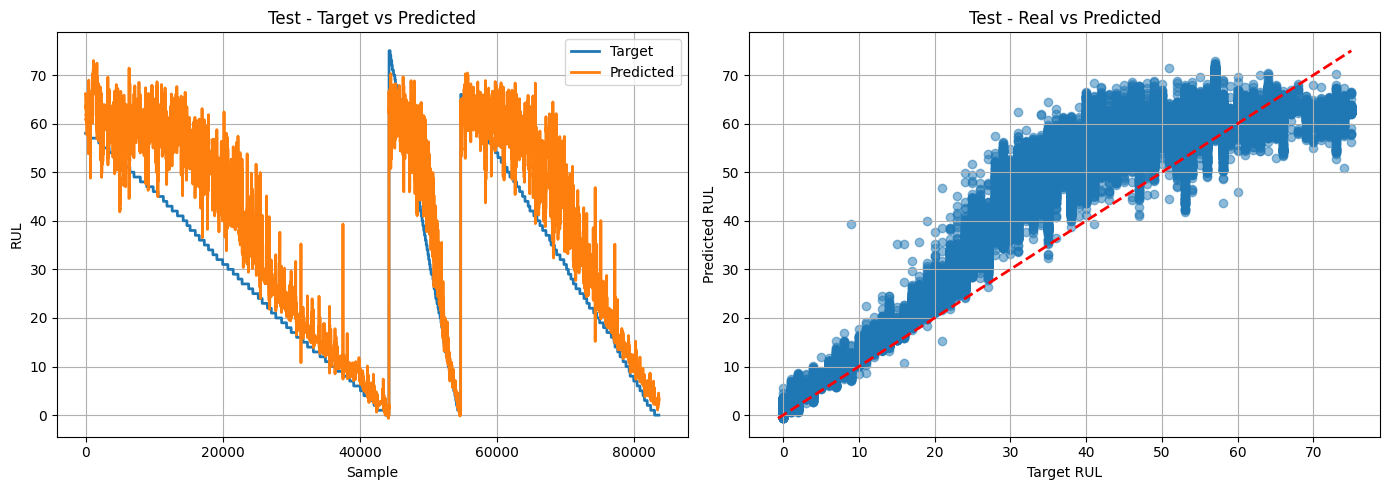

Configuration: lr: 0.0001, dropout: 0.3, num of channels : (64, 64, 128), kernel size: 5
cuda
cuda:0
Epoch 1/20 - LR: 0.000100 - Train Loss: 259.4109 - Train RMSE: 16.1062 - Train NASA mean: 4.2341 - Train NASA total: 1234237.01 - Val Loss: 106.9306 - Val RMSE: 10.3407 - Val NASA mean: 1.2918 - Val NASA total: 76706.70
Epoch 2/20 - LR: 0.000100 - Train Loss: 109.8547 - Train RMSE: 10.4812 - Train NASA mean: 1.5403 - Train NASA total: 448993.59 - Val Loss: 65.1236 - Val RMSE: 8.0699 - Val NASA mean: 1.0633 - Val NASA total: 63135.36
Epoch 3/20 - LR: 0.000100 - Train Loss: 89.7812 - Train RMSE: 9.4753 - Train NASA mean: 1.2701 - Train NASA total: 370241.89 - Val Loss: 48.4065 - Val RMSE: 6.9575 - Val NASA mean: 0.7965 - Val NASA total: 47296.04
Epoch 4/20 - LR: 0.000100 - Train Loss: 80.3931 - Train RMSE: 8.9662 - Train NASA mean: 1.1473 - Train NASA total: 334448.74 - Val Loss: 41.4126 - Val RMSE: 6.4353 - Val NASA mean: 0.6243 - Val NASA total: 37070.68
Epoch 5/20 - LR: 0.000100 - Trai

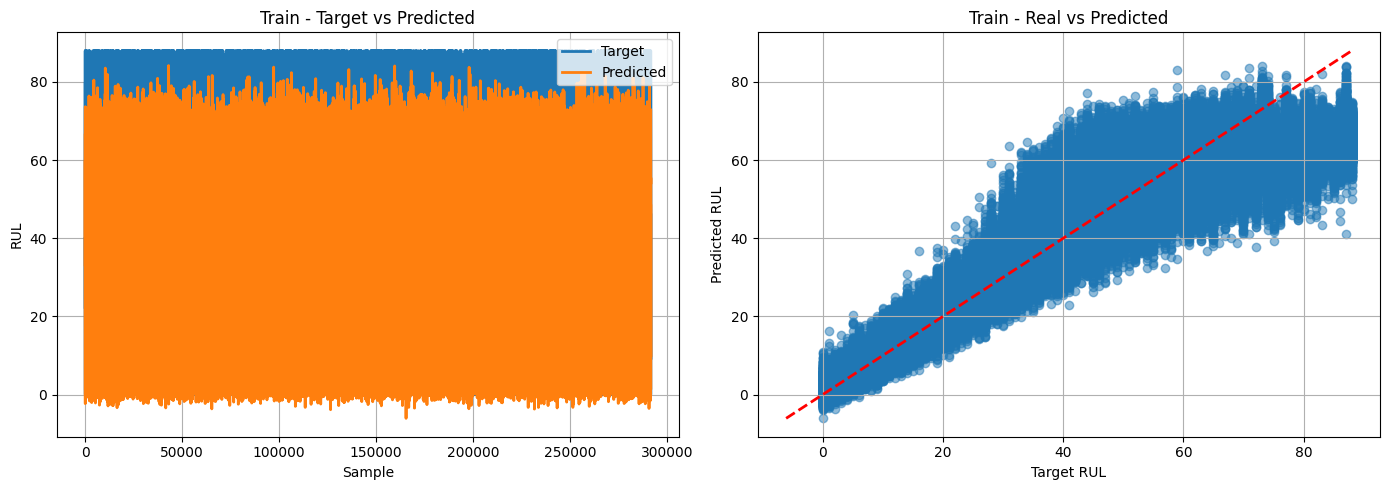

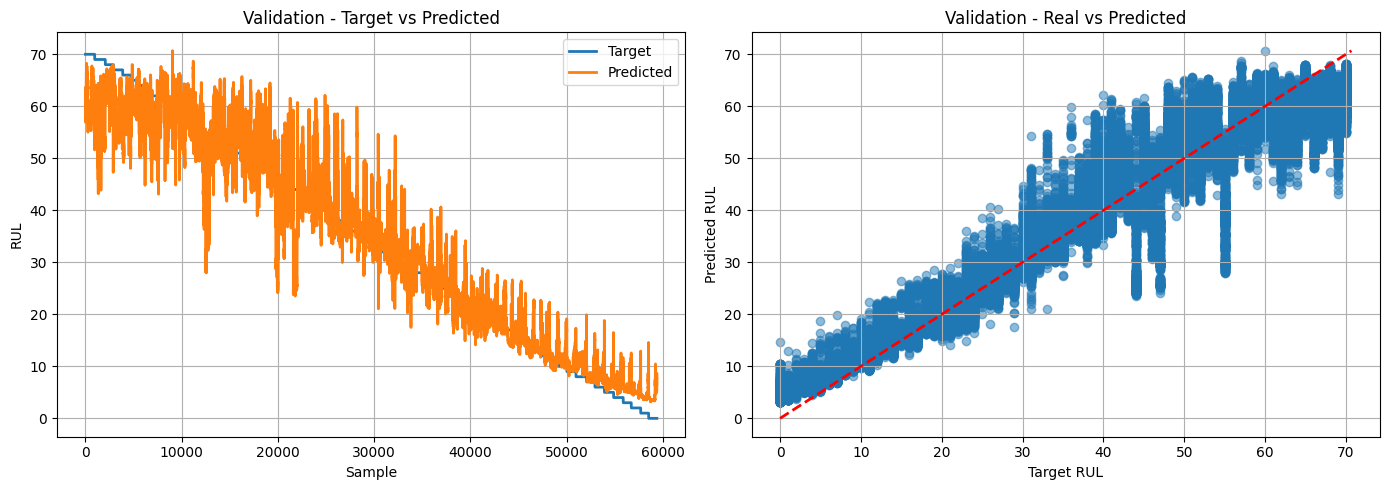

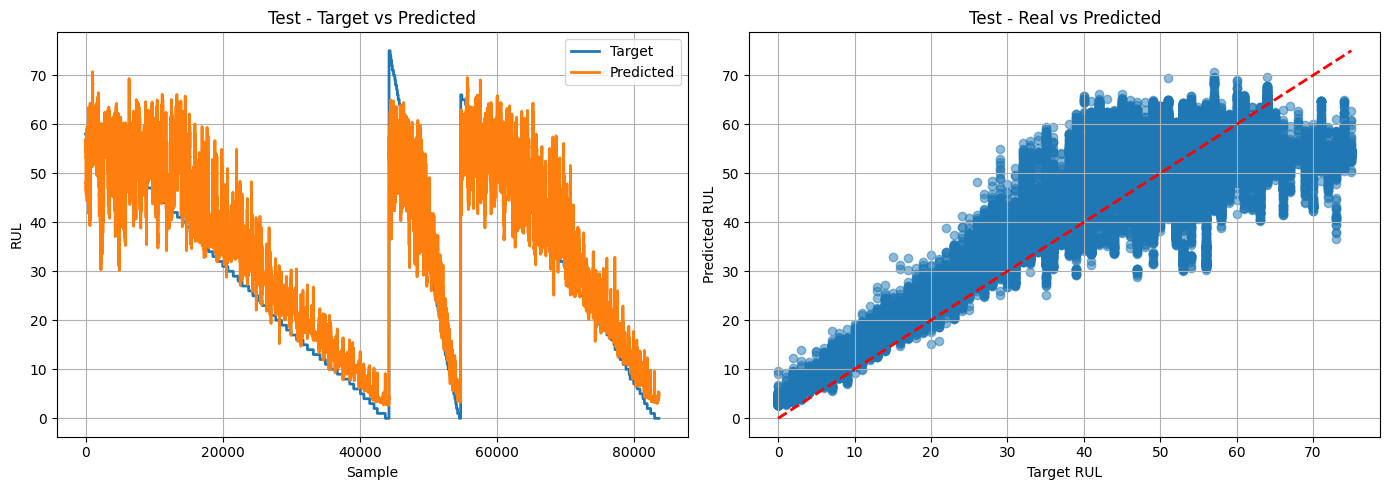

In [ ]:
search_space = [
    {"lr": 1e-3, "dropout": 0.1, "num_channels": (32, 64, 64), "kernel_size": 3},
    {"lr": 5e-4, "dropout": 0.2, "num_channels": (64, 64, 64), "kernel_size": 4},
    {"lr": 1e-4, "dropout": 0.3, "num_channels": (64, 64, 128), "kernel_size": 5},
]

best_val_rmse = float("inf")
best_config = None

for config in search_space:
    model = TCNRegressor(
    num_features=len(features),
    num_channels=config['num_channels'],
    kernel_size=config['kernel_size'],
    dropout=config['dropout']
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=1e-4
    )

    print(f'Configuration: lr: {config["lr"]}, dropout: {config["dropout"]}, num of channels : {config["num_channels"]}, kernel size: {config["kernel_size"]}')

    trained_model, train_preds, train_targets, val_preds, val_targets = train(
    criterion, optimizer, train_loader, val_loader, model, num_epochs=20
    )

    test_loss, test_rmse, test_nasa, test_preds, test_targets = test(trained_model, test_loader, criterion)
    # evaluate val RMSE here and compare
    plot_predictions(train_targets, train_preds, split_name="Train")
    plot_predictions(val_targets, val_preds, split_name="Validation")
    plot_predictions(test_targets, test_preds, split_name="Test")

## **Optuna parameters tunning**

#### **physical & virtual sensors**

In [ ]:
!pip install optuna

In [ ]:
import optuna


def objective(trial):

    # Hyperparameters to tune
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    num_channels = trial.suggest_categorical(
        "num_channels",
        [
            (32, 64, 64),
            (64, 64, 64),
            (64, 64, 128),
        ],
    )

    kernel_size = trial.suggest_categorical("kernel_size", [3, 4, 5])

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True,
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128],
    )

    num_epochs = trial.suggest_categorical(
        "num_epochs",
        [20, 40, 60],
    )

    window_size = trial.suggest_categorical(
        "window_size",
        [50, 100, 500],
    )

    stride = trial.suggest_categorical(
        "stride",
        [15, 20, 30, 40, 150, 200],
    )

    # Only allow valid stride/window combinations
    valid_strides = {
        50: [15, 20],
        100: [30, 40],
        500: [150, 200],
    }

    if stride not in valid_strides[window_size]:
        raise optuna.TrialPruned()

    # -----------------------------
    # Create datasets
    # -----------------------------

    train_engine_df = X_train_scaled_df[X_train_scaled_df["unit"] != 18]
    val_engine_df = X_train_scaled_df[X_train_scaled_df["unit"] == 18]

    X_windows_train, Y_windows_train = create_windows(
        train_engine_df,
        features,
        window_size=window_size,
        stride=stride,
    )

    X_windows_val, Y_windows_val = create_windows(
        val_engine_df,
        features,
        window_size=window_size,
        stride=stride,
    )

    X_windows_test, Y_windows_test = create_windows(
        X_test_scaled_df,
        features,
        window_size=window_size,
        stride=stride,
    )

    dataset_train = CMAPSS(X_windows_train, Y_windows_train)
    dataset_val = CMAPSS(X_windows_val, Y_windows_val)
    dataset_test = CMAPSS(X_windows_test, Y_windows_test)

    train_loader = DataLoader(
        dataset_train,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        dataset_val,
        batch_size=batch_size,
        shuffle=False,
    )

    test_loader = DataLoader(
        dataset_test,
        batch_size=batch_size,
        shuffle=False,
    )

    # -----------------------------
    # Model
    # -----------------------------

    model = TCNRegressor(
        num_features=len(features),
        num_channels=num_channels,
        kernel_size=kernel_size,
        dropout=dropout,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    criterion = torch.nn.MSELoss()

    # -----------------------------
    # Training
    # -----------------------------

    model, train_preds, train_targets, val_preds, val_targets = train(
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        model=model,
        num_epochs=num_epochs,
    )

    # -----------------------------
    # Evaluation
    # -----------------------------

    test_loss, test_rmse, test_nasa, test_preds, test_targets = test(
        model,
        test_loader,
        criterion,
    )

    
    return test_rmse


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print(study.best_params)
print(study.best_value)

C:\Users\Student\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-13 09:41:17,366] A new study created in memory with name: no-name-ea08cf7f-966d-4cfb-a7e8-74d5063ab15b
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\i

cuda
cuda:0
Epoch 1/60 - LR: 0.000899 - Train Loss: 604.1459 - Train RMSE: 24.5794 - Train NASA mean: 12.3503 - Train NASA total: 269902.97 - Val Loss: 424.2578 - Val RMSE: 20.5975 - Val NASA mean: 6.7345 - Val NASA total: 29982.04
Epoch 2/60 - LR: 0.000899 - Train Loss: 481.5813 - Train RMSE: 21.9450 - Train NASA mean: 7.9999 - Train NASA total: 174830.57 - Val Loss: 349.8825 - Val RMSE: 18.7051 - Val NASA mean: 5.1110 - Val NASA total: 22753.98
Epoch 3/60 - LR: 0.000899 - Train Loss: 319.7920 - Train RMSE: 17.8827 - Train NASA mean: 4.9281 - Train NASA total: 107697.89 - Val Loss: 168.6332 - Val RMSE: 12.9859 - Val NASA mean: 2.5888 - Val NASA total: 11525.18
Epoch 4/60 - LR: 0.000899 - Train Loss: 199.8611 - Train RMSE: 14.1372 - Train NASA mean: 2.9025 - Train NASA total: 63430.65 - Val Loss: 78.1879 - Val RMSE: 8.8424 - Val NASA mean: 1.0333 - Val NASA total: 4600.41
Epoch 5/60 - LR: 0.000899 - Train Loss: 170.8341 - Train RMSE: 13.0704 - Train NASA mean: 2.4360 - Train NASA total

[I 2026-07-13 09:42:04,566] Trial 2 finished with value: 12.242128372192383 and parameters: {'lr': 0.0008990124389424687, 'dropout': 0.2267067212726669, 'num_channels': (32, 64, 64), 'kernel_size': 5, 'weight_decay': 0.0002228691260881702, 'batch_size': 128, 'num_epochs': 60, 'window_size': 500, 'stride': 200}. Best is trial 2 with value: 12.242128372192383.
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\15154609

cuda
cuda:0
Epoch 1/20 - LR: 0.000011 - Train Loss: 1892.7365 - Train RMSE: 43.5056 - Train NASA mean: 64.5927 - Train NASA total: 1882101.69 - Val Loss: 1459.1302 - Val RMSE: 38.1986 - Val NASA mean: 33.3691 - Val NASA total: 198045.36
Epoch 2/20 - LR: 0.000011 - Train Loss: 1501.0837 - Train RMSE: 38.7438 - Train NASA mean: 42.0746 - Train NASA total: 1225971.07 - Val Loss: 846.7067 - Val RMSE: 29.0982 - Val NASA mean: 13.4566 - Val NASA total: 79865.18
Epoch 3/20 - LR: 0.000011 - Train Loss: 708.3746 - Train RMSE: 26.6153 - Train NASA mean: 12.4649 - Train NASA total: 363203.34 - Val Loss: 458.2006 - Val RMSE: 21.4056 - Val NASA mean: 7.9982 - Val NASA total: 47469.14
Epoch 4/20 - LR: 0.000011 - Train Loss: 556.7293 - Train RMSE: 23.5951 - Train NASA mean: 10.1059 - Train NASA total: 294466.92 - Val Loss: 456.2976 - Val RMSE: 21.3611 - Val NASA mean: 8.0618 - Val NASA total: 47846.49
Epoch 5/20 - LR: 0.000011 - Train Loss: 550.7413 - Train RMSE: 23.4679 - Train NASA mean: 9.9129 - T

[I 2026-07-13 09:43:22,965] Trial 3 finished with value: 19.19134521484375 and parameters: {'lr': 1.0653793160962932e-05, 'dropout': 0.10857815393923227, 'num_channels': (64, 64, 64), 'kernel_size': 3, 'weight_decay': 1.7696645733047547e-06, 'batch_size': 128, 'num_epochs': 20, 'window_size': 500, 'stride': 150}. Best is trial 2 with value: 12.242128372192383.
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\151546

...

cuda
cuda:0
Epoch 1/60 - LR: 0.000042 - Train Loss: 856.5084 - Train RMSE: 29.2662 - Train NASA mean: 21.6732 - Train NASA total: 631513.78 - Val Loss: 478.6064 - Val RMSE: 21.8771 - Val NASA mean: 6.1565 - Val NASA total: 36538.62
Epoch 2/60 - LR: 0.000042 - Train Loss: 563.4360 - Train RMSE: 23.7368 - Train NASA mean: 10.5099 - Train NASA total: 306237.12 - Val Loss: 453.9454 - Val RMSE: 21.3060 - Val NASA mean: 5.8812 - Val NASA total: 34904.87
Epoch 3/60 - LR: 0.000042 - Train Loss: 531.1893 - Train RMSE: 23.0475 - Train NASA mean: 9.3964 - Train NASA total: 273792.64 - Val Loss: 465.0693 - Val RMSE: 21.5655 - Val NASA mean: 5.9179 - Val NASA total: 35122.92
Epoch 4/60 - LR: 0.000042 - Train Loss: 514.3483 - Train RMSE: 22.6792 - Train NASA mean: 8.8932 - Train NASA total: 259129.83 - Val Loss: 456.2619 - Val RMSE: 21.3603 - Val NASA mean: 5.7124 - Val NASA total: 33902.86
Epoch 5/60 - LR: 0.000042 - Train Loss: 484.6135 - Train RMSE: 22.0139 - Train NASA mean: 8.0569 - Train NASA 

[I 2026-07-13 09:57:24,189] Trial 22 finished with value: 12.307486534118652 and parameters: {'lr': 4.1594212711342066e-05, 'dropout': 0.39910699627205226, 'num_channels': (64, 64, 64), 'kernel_size': 5, 'weight_decay': 0.00048046589155655874, 'batch_size': 64, 'num_epochs': 60, 'window_size': 500, 'stride': 150}. Best is trial 17 with value: 6.517533779144287.
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\15154

cuda
cuda:0
Epoch 1/60 - LR: 0.000141 - Train Loss: 632.1275 - Train RMSE: 25.1421 - Train NASA mean: 13.3333 - Train NASA total: 388506.88 - Val Loss: 517.2949 - Val RMSE: 22.7441 - Val NASA mean: 6.5455 - Val NASA total: 38847.43
Epoch 2/60 - LR: 0.000141 - Train Loss: 517.0461 - Train RMSE: 22.7386 - Train NASA mean: 9.0434 - Train NASA total: 263507.97 - Val Loss: 410.5637 - Val RMSE: 20.2624 - Val NASA mean: 5.1211 - Val NASA total: 30393.58
Epoch 3/60 - LR: 0.000141 - Train Loss: 380.6612 - Train RMSE: 19.5105 - Train NASA mean: 6.2059 - Train NASA total: 180828.93 - Val Loss: 250.3825 - Val RMSE: 15.8235 - Val NASA mean: 2.7251 - Val NASA total: 16173.22
Epoch 4/60 - LR: 0.000141 - Train Loss: 220.0123 - Train RMSE: 14.8328 - Train NASA mean: 3.3853 - Train NASA total: 98642.30 - Val Loss: 280.3702 - Val RMSE: 16.7443 - Val NASA mean: 3.0073 - Val NASA total: 17848.31
Epoch 5/60 - LR: 0.000141 - Train Loss: 180.0459 - Train RMSE: 13.4181 - Train NASA mean: 2.6476 - Train NASA to

[I 2026-07-13 09:58:24,316] Trial 23 finished with value: 6.360764026641846 and parameters: {'lr': 0.00014065145501131784, 'dropout': 0.4686616610853806, 'num_channels': (64, 64, 64), 'kernel_size': 5, 'weight_decay': 0.0001058500361016719, 'batch_size': 64, 'num_epochs': 60, 'window_size': 500, 'stride': 150}. Best is trial 23 with value: 6.360764026641846.
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_9352\15154609

{'lr': 0.00014065145501131784, 'dropout': 0.4686616610853806, 'num_channels': (64, 64, 64), 'kernel_size': 5, 'weight_decay': 0.0001058500361016719, 'batch_size': 64, 'num_epochs': 60, 'window_size': 500, 'stride': 150}
6.360764026641846


### **Best hyperparameters from Optuna**

In [7]:
best_params = study.best_params
print(best_params)
print("Best validation RMSE:", study.best_value)

print("=" * 100)
print("=" * 100)

top3 = sorted(
    [t for t in study.trials if t.value is not None],
    key=lambda t: t.value
)[:3]

# Print best three trials
for i, trial in enumerate(top3, 1):
    print(f"Top {i}: Validation RMSE = {trial.value:.4f}")
    print(trial.params)
    print()

# Best hyperparameters
best_window_size = best_params["window_size"]
best_stride = best_params["stride"]
best_num_channels = best_params["num_channels"]
best_kernel_size = best_params["kernel_size"]
best_dropout = best_params["dropout"]
best_weight_decay = best_params["weight_decay"]
best_batch_size = best_params["batch_size"]
best_lr = best_params["lr"]
best_num_epochs = best_params["num_epochs"]

print(
    f"best_window_size: {best_window_size}\n"
    f"best_stride: {best_stride}\n"
    f"best_num_channels: {best_num_channels}\n"
    f"best_kernel_size: {best_kernel_size}\n"
    f"best_dropout: {best_dropout}\n"
    f"best_weight_decay: {best_weight_decay}\n"
    f"best_batch_size: {best_batch_size}\n"
    f"best_lr: {best_lr}\n"
    f"best_num_epochs: {best_num_epochs}"
)

{'lr': 0.00014065145501131784, 'dropout': 0.4686616610853806, 'num_channels': (64, 64, 64), 'kernel_size': 5, 'weight_decay': 0.0001058500361016719, 'batch_size': 64, 'num_epochs': 60, 'window_size': 500, 'stride': 150}
Best validation RMSE: 6.360764026641846
Top 1: Validation RMSE = 6.3608
{'lr': 0.00014065145501131784, 'dropout': 0.4686616610853806, 'num_channels': (64, 64, 64), 'kernel_size': 5, 'weight_decay': 0.0001058500361016719, 'batch_size': 64, 'num_epochs': 60, 'window_size': 500, 'stride': 150}

Top 2: Validation RMSE = 6.5175
{'lr': 0.00018137937324434297, 'dropout': 0.4168251642780529, 'num_channels': (64, 64, 128), 'kernel_size': 5, 'weight_decay': 0.00013719971526018288, 'batch_size': 32, 'num_epochs': 60, 'window_size': 500, 'stride': 200}

Top 3: Validation RMSE = 6.6129
{'lr': 0.000969672148855026, 'dropout': 0.4895809979970012, 'num_channels': (64, 64, 128), 'kernel_size': 5, 'weight_decay': 5.132401736175995e-05, 'batch_size': 64, 'num_epochs': 60, 'window_size': 5

## **Retrain with the best hyperparameters from Optuna**

Shape of train_engine_df: (4372728, 35) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 35) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 35) and engine units: [11 14 15]
X train normalized windows shape: (29138, 500, 32) 
 Y train windows  shape: (29138,)
X val windows shape: (5935, 500, 32) 
 Y val windows  shape: (5935,)
X test windows shape: (8349, 500, 32) 
 Y test windows  shape: (8349,)
cuda
cuda:0
Epoch 1/40 - LR: 0.000141 - Train Loss: 689.6277 - Train RMSE: 26.2608 - Train NASA mean: 16.3588 - Train NASA total: 476663.06 - Val Loss: 547.3097 - Val RMSE: 23.3947 - Val NASA mean: 7.0369 - Val NASA total: 41764.03
Epoch 2/40 - LR: 0.000141 - Train Loss: 530.7915 - Train RMSE: 23.0389 - Train NASA mean: 9.4816 - Train NASA total: 276273.94 - Val Loss: 515.1848 - Val RMSE: 22.6977 - Val NASA mean: 6.5267 - Val NASA total: 38735.74
Epoch 3/40 - LR: 0.000141 - Train Loss: 466.9592 - Train RMSE: 21.6092 - Train NASA mean: 7.7063 - Train NASA total: 2

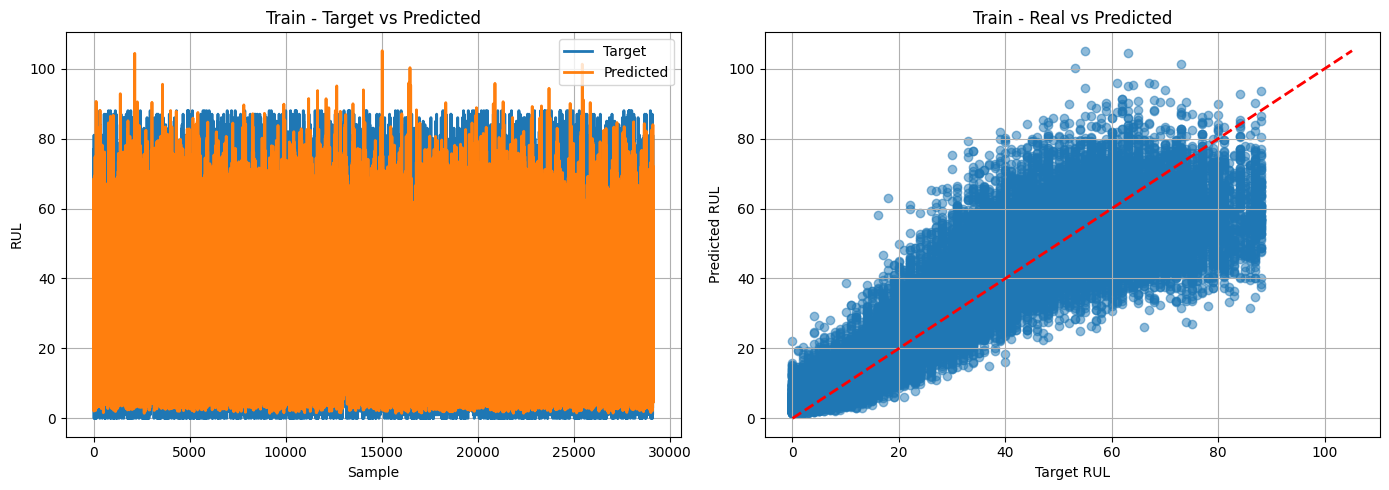

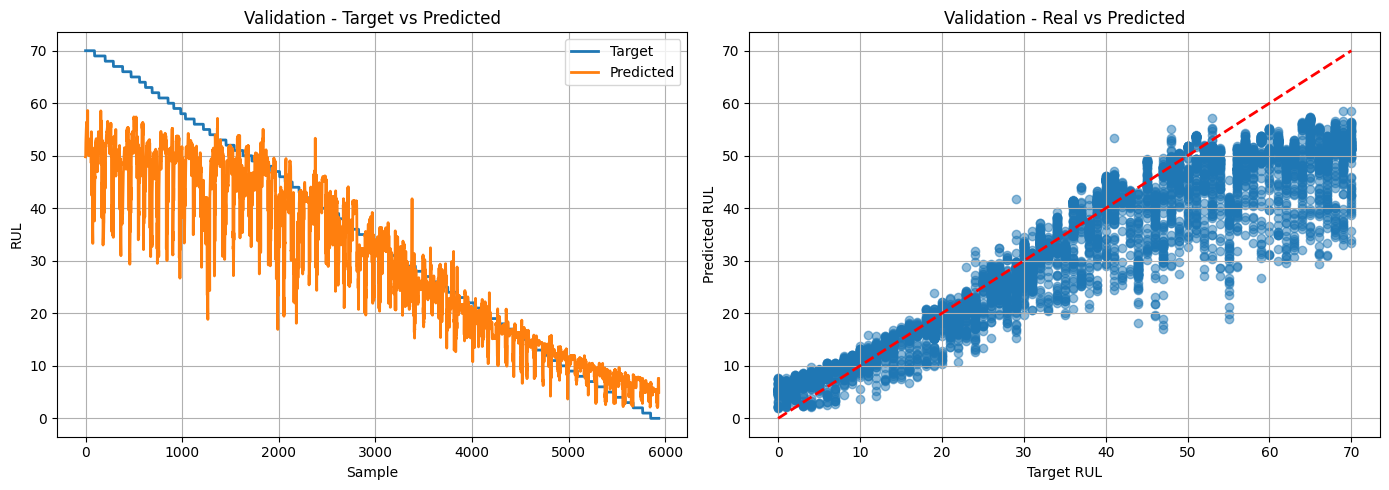

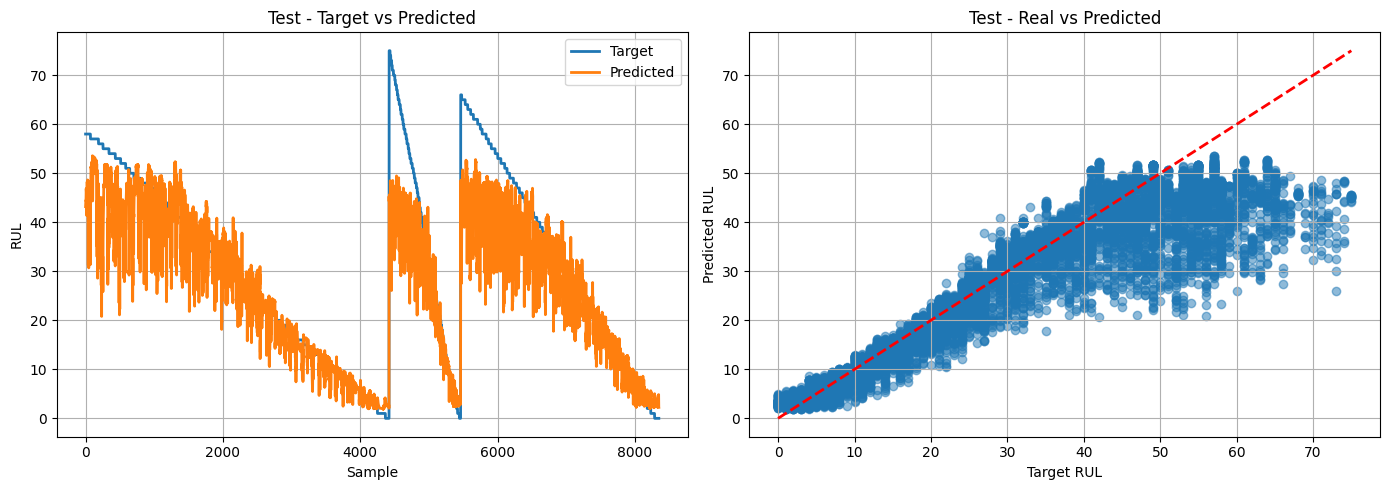

In [ ]:
train_engine_df = X_train_scaled_df[X_train_scaled_df['unit'] != 18]
val_engine_df   = X_train_scaled_df[X_train_scaled_df['unit'] == 18]

print(f"Shape of train_engine_df: {train_engine_df.shape} and engine units: {train_engine_df['unit'].unique()}")
print(f"Shape of val_engine_df: {val_engine_df.shape} and engine units: {val_engine_df['unit'].unique()}")
print(f"Shape of X_test_scaled_df: {X_test_scaled_df.shape} and engine units: {X_test_scaled_df['unit'].unique()}")

X_windows_train, Y_windows_train = create_windows(train_engine_df, features, window_size=best_window_size, stride=best_stride)
X_windows_val, Y_windows_val     = create_windows(val_engine_df, features, window_size=best_window_size, stride=best_stride)
X_windows_test, Y_windows_test = create_windows(X_test_scaled_df, features, window_size=best_window_size, stride=best_stride)

print("X train normalized windows shape:",X_windows_train.shape,"\n Y train windows  shape:" , Y_windows_train.shape) 
print("X val windows shape:",X_windows_val.shape,"\n Y val windows  shape:" , Y_windows_val.shape) # engine (18) for validating
print("X test windows shape:",X_windows_test.shape,"\n Y test windows  shape:" , Y_windows_test.shape) 

dataset_train = CMAPSS(X_windows_train, Y_windows_train)
dataset_val   = CMAPSS(X_windows_val, Y_windows_val)
dataset_test  = CMAPSS(X_windows_test, Y_windows_test)

train_loader = DataLoader(dataset_train, batch_size=best_batch_size, shuffle=True)
val_loader   = DataLoader(dataset_val, batch_size=best_batch_size, shuffle=False)
test_loader  = DataLoader(dataset_test, batch_size=best_batch_size, shuffle=False)

model = TCNRegressor(
    num_features=len(features),
    num_channels=best_num_channels,
    kernel_size=best_kernel_size,
    dropout=best_dropout,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_lr,
    weight_decay=best_weight_decay
)

criterion = torch.nn.MSELoss()

model, train_preds, train_targets, val_preds, val_targets = train(
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    num_epochs=40 
)

test_loss, test_rmse, test_nasa, test_preds, test_targets = test(model, test_loader, criterion)  # or val NASA score

plot_predictions(train_targets, train_preds, split_name="Train")
plot_predictions(val_targets, val_preds, split_name="Validation")
plot_predictions(test_targets, test_preds, split_name="Test")